<a href="https://colab.research.google.com/github/azrapatvi/dl-practice/blob/main/11_cnn_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.layers import Conv2D,Dense,Flatten
from tensorflow.keras import Sequential
from keras.datasets import mnist

In [2]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

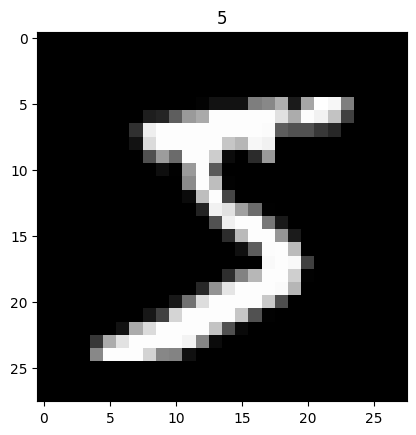

In [4]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap="gray")
plt.title(y_train[0])
plt.show()

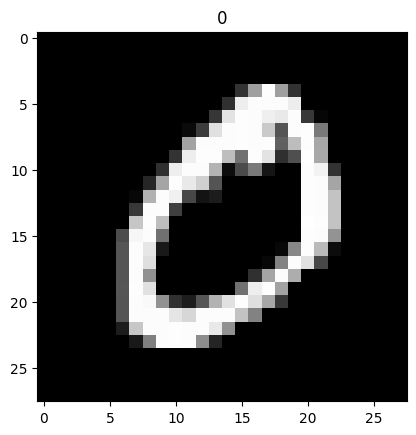

In [5]:
import matplotlib.pyplot as plt

plt.imshow(X_train[1], cmap="gray")
plt.title(y_train[1])
plt.show()

In [6]:
X_train[0].shape

(28, 28)

In [7]:
X_train.shape

(60000, 28, 28)

In [8]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [9]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [10]:
# from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D

# model=Sequential()

# #padding valid menas no padding gets addedd
# model.add(Conv2D(72,activation='relu',padding='valid',kernel_size=(3,3),input_shape=(28,28,1)))
# model.add(MaxPooling2D(pool_size=(2,2)))
# model.add(Conv2D(72,activation='relu',padding='valid',kernel_size=(3,3)))
# model.add(MaxPooling2D(pool_size=(2,2)))
# model.add(Conv2D(72,activation='relu',padding='valid',kernel_size=(3,3)))
# model.add(MaxPooling2D(pool_size=(2,2)))

# model.add(Flatten())

# # fully connected layer
# model.add(Dense(128,activation='relu'))
# model.add(Dense(10,activation='softmax'))

In [11]:
# model.summary()

In [12]:
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D
model=Sequential()

#padding valid menas no padding gets addedd
model.add(Conv2D(72,activation='relu',padding='same',kernel_size=(3,3),input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(72,activation='relu',padding='same',kernel_size=(3,3)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(72,activation='relu',padding='same',kernel_size=(3,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

# fully connected layer
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 72)     │           720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 72)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 72)     │        46,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 72)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 72)       │        46,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 72)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 648)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        83,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,538 (697.41 KB)

 Trainable params: 178,538 (697.41 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9489 - loss: 0.1656 - val_accuracy: 0.9870 - val_loss: 0.0462
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9866 - loss: 0.0430 - val_accuracy: 0.9898 - val_loss: 0.0388
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9894 - loss: 0.0322 - val_accuracy: 0.9910 - val_loss: 0.0282
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9923 - loss: 0.0240 - val_accuracy: 0.9908 - val_loss: 0.0294
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9936 - loss: 0.0199 - val_accuracy: 0.9908 - val_loss: 0.0373
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9945 - loss: 0.0173 - val_accuracy: 0.9882 - val_loss: 0.0446
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9948 - loss: 0.0139 - val_accuracy: 0.9945 - val_loss: 0.0273
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9964 - loss: 0.0106 - val_accuracy: 0

In [16]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9924 - loss: 0.0260
Test Accuracy: 0.9923999905586243


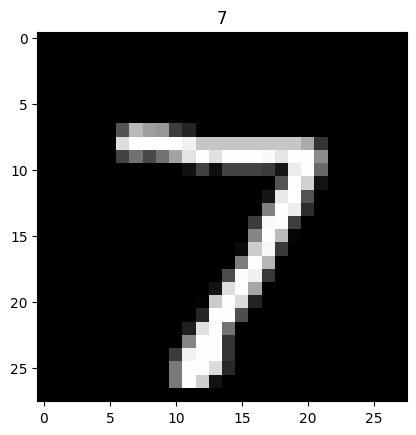

In [18]:
plt.imshow(X_test[0], cmap="gray")
plt.title(y_test[0])
plt.show()

In [19]:
import numpy as np

prediction = model.predict(X_test[0].reshape(1,28,28,1))

print(prediction)
print("Predicted digit:", np.argmax(prediction)) # finds the position or largeest value
print("Actual digit:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[[1.1089363e-10 3.2537891e-08 3.4982531e-07 8.4479971e-08 2.5188365e-11
  7.2623413e-10 2.2118195e-14 9.9999940e-01 2.3727114e-09 1.1991806e-07]]
Predicted digit: 7
Actual digit: 7
